In [21]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from scipy.stats import wilcoxon

In [81]:
IMG_SIZE=512
#standardising images to 512 to help the model (why 512:big enough to keep useful details for segmentation)
def load_data(img_paths, mask_paths):
  X,Y = [], []
  for ipath, mpath in zip(img_paths, mask_paths):
    img= cv2.imread(ipath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0

    mask= cv2.imread(mpath, cv2.IMREAD_GRAYSCALE)
    mask= cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask= (mask > 0).astype(np.uint8)     # ensures binary
    mask = mask[..., None]

    X.append(img)
    Y.append(mask)
  return np.array(X), np.array(Y)

In [82]:
#Hough is a quick classical method to get a "region of interest" without a model.
#Hough is edge/gradient based: blur reduces tiny edges/noise so circle detection is more stable.
#It works as a quick ROI mask
def cornea_mask_hough(rgbImg, rmin=60, rmax=200):
  #rgb image  in [0,1] and shape (H,W,3)
  img= (rgbImg*255).astype(np.uint8)
  gray= cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  gray =  cv2.GaussianBlur(gray, (7,7), 0)

  circles=cv2.HoughCircles(
        gray,cv2.HOUGH_GRADIENT,
        dp=1.2, minDist=gray.shape[0]//2,
        param1=120,param2=30,
        minRadius=rmin, maxRadius=rmax
    )
  mask= np.zeros(gray.shape[:2], dtype=np.uint8)
  if circles is None:
    return mask  #all zeros if not found
  x,y,r = np.round(circles[0][0]).astype(int)
  cv2.circle(mask, (x,y), r, 1, -1)
  return mask


In [83]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

BASE="/content/drive/MyDrive/Corneal_ulcer_model"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
X_train= np.load(os.path.join(BASE,"train_images.npy")).astype(np.float32)
Y_train= np.load(os.path.join(BASE,  "train_ulcer.npy")).astype(np.uint8)

X_val =np.load(os.path.join(BASE, "val_images.npy")).astype(np.float32)
Y_val=np.load(os.path.join(BASE,"val_ulcer.npy")).astype(np.uint8)

X_test=np.load(os.path.join(BASE, "test_images.npy")).astype(np.float32)
Y_test=np.load(os.path.join(BASE, "test_ulcer.npy")).astype(np.uint8)

#ensuring channel dim for masks
if Y_train.ndim ==3:Y_train = Y_train[...,None]
if Y_val.ndim ==3:Y_val = Y_val[...,None]
if Y_test.ndim ==3:Y_test = Y_test[...,None]

print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)

(247, 256, 256, 3) (247, 256, 256, 1) (72, 256, 256, 3) (72, 256, 256, 1)


In [85]:
#mix between background and ulcer pixels
#use only for synthetic data nto real

Y_train_ulcer= 1 - Y_train
Y_val_ulcer = 1 - Y_val
Y_test_ulcer = 1 - Y_test

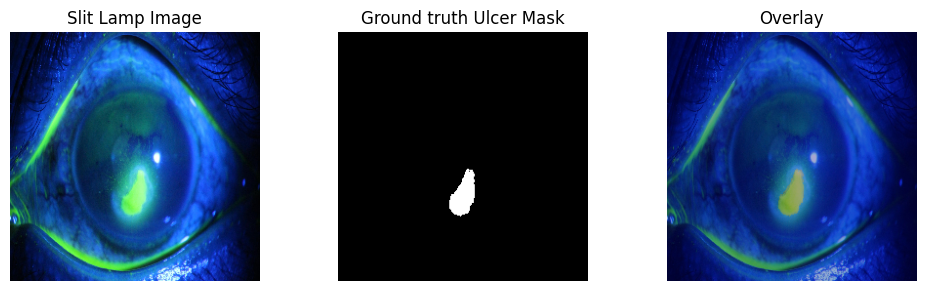

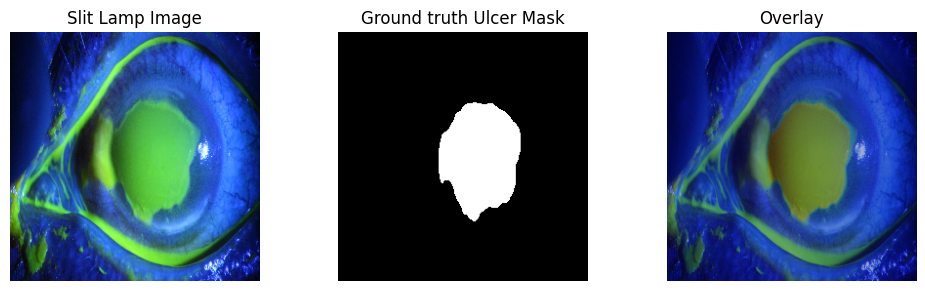

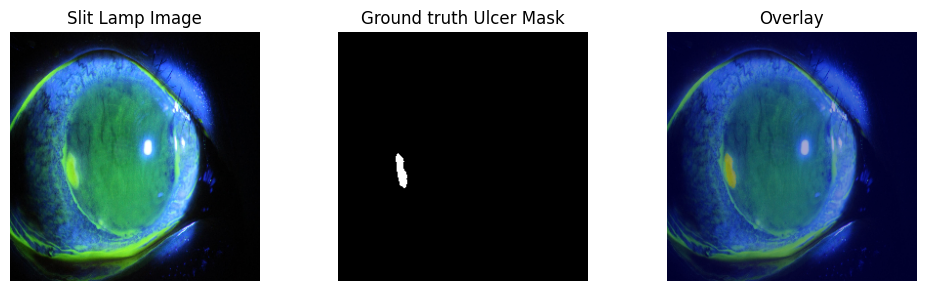

In [86]:
def show_sample(i=0):
  img= X_train[i]
  gt=Y_train_ulcer[i,...,0]
  plt.figure(figsize=(10,3))
  plt.subplot(1,3,1); plt.imshow(img); plt.title("Slit Lamp Image"); plt.axis("off")
  plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("Ground truth Ulcer Mask");plt.axis("off")
  plt.subplot(1,3,3); plt.imshow(img); plt.imshow(gt, alpha=0.35, cmap="jet"); plt.title("Overlay"); plt.axis("off")
  plt.tight_layout(); plt.show()

show_sample(0)
show_sample(12)
show_sample(20)


In [87]:
def convBlock(x,f):
  #feature extractor blocks
  x = layers.Conv2D(f, 3, padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)
  x = layers.Conv2D(f, 3, padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)
  return x

def buildUnet(inputShape):
  inp = layers.Input(shape=inputShape)
  c1 = convBlock(inp, 32); p1 = layers.MaxPool2D()(c1)
  c2 = convBlock(p1, 64);  p2 = layers.MaxPool2D()(c2)
  c3 = convBlock(p2, 128); p3 = layers.MaxPool2D()(c3)
  c4 = convBlock(p3, 256); p4 = layers.MaxPool2D()(c4)
  bn = convBlock(p4, 512)
#upSampling2D is simpler and avoids some checkerboard artefacts/Conv2DTranspose can learn better upsampling but may introduce artefacts if not tuned
  u1 = layers.UpSampling2D()(bn); u1= layers.Concatenate()([u1, c4]); c5 = convBlock(u1, 256)
  u2 = layers.UpSampling2D()(c5); u2= layers.Concatenate()([u2, c3]); c6 = convBlock(u2, 128)
  u3 = layers.UpSampling2D()(c6); u3= layers.Concatenate()([u3, c2]); c7 = convBlock(u3, 64)
  u4 = layers.UpSampling2D()(c7); u4= layers.Concatenate()([u4, c1]); c8 = convBlock(u4, 32)

#used sigmoid instead of softmax because mask is binary:we dont have multiple classes
  out = layers.Conv2D(1, 1,activation="sigmoid")(c8)  #predicts P(ulcer) per pixel
  return Model(inp, out)

modelReal = buildUnet(X_train.shape[1:])
modelReal.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │      9,248 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ activation_39[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_42[0][0] 

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [89]:
#a Dice like overlap score with weighted penalties : alpha for false postives and beta false negatives
#why this loss: Ulcer pixels are likely a small fraction of the image
def focal_tversky_loss(y_true,y_pred,alpha=0.7,beta=0.3,gamma=0.75,eps=1e-6):
  #I am penalising false positives more than false negatives -> missing ulcers is worse clinically we want beta>alpha
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred, tf.float32)
  tp = tf.reduce_sum(y_true * y_pred)
  fp= tf.reduce_sum((1-y_true) * y_pred)
  fn= tf.reduce_sum(y_true * (1-y_pred))
  tversky= (tp + eps) /(tp + alpha*fp + beta*fn + eps)
  return tf.pow((1 - tversky), gamma)


In [92]:
modelReal.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss=focal_tversky_loss)

In [93]:
model_path= "/content/drive/MyDrive/Corneal_ulcer_model/models/RealDataModelv2.keras"
#saves the best model + Stops training if no improvement for 10 epochs and restores best weights
#I am monitoring val_loss becaseu the loss aligns with training objective and i am adding dice /iou later

cb=[tf.keras.callbacks.ModelCheckpoint(model_path,save_best_only=True,monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True,monitor="val_loss")]

hist= modelReal.fit(X_train, Y_train_ulcer,validation_data=(X_val, Y_val_ulcer),epochs=60,batch_size=8,callbacks=cb,verbose=1)


Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 645ms/step - loss: 0.9391 - val_loss: 0.9584
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - loss: 0.9055 - val_loss: 0.9585
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - loss: 0.8846 - val_loss: 0.9594
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - loss: 0.8743 - val_loss: 0.9589
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - loss: 0.8647 - val_loss: 0.9589
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - loss: 0.8577 - val_loss: 0.9578
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - loss: 0.8538 - val_loss: 0.9590
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - loss: 0.8488 - val_loss: 0.9587
Epoch 9/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - loss: 0.8440 - val_loss: 0.9582
Epoch 10/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - loss: 0.8376 - val_loss: 0.9574
Epoch 11/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - loss: 0.8335 - val_loss: 0.9464
Epoch 12/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/ste

In [98]:
#Measures overlap quality and its Sensitive to small objects (good for ulcers)
def diceNp(a,b,eps=1e-6):
  a=a.reshape(-1); b=b.reshape(-1)
  return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

#Harsher than Dice and Penalises over segmentation more
#eps prevents division over 0 if both masks are empty
def iouNp(a,b,eps=1e-6):
  a=a.reshape(-1).astype(np.uint8)
  b=b.reshape(-1).astype(np.uint8)
  inter= np.logical_and(a,b).sum()
  union= np.logical_or(a,b).sum()
  return (inter+eps)/(union+eps)

def evalModel(model, X, Y_ulcer,threshold=0.5,useRoi=False):
  probs = model.predict(X, verbose=0)[...,0]  # PROBABILITY(ulcer)
  pred_bin =(probs > threshold).astype(np.uint8)
  groundTruth = Y_ulcer[...,0].astype(np.uint8)

#Without ROI: measures overall robustness
#With ROI: focuses on clinically relevant region
#useRoi Computes a cornea mask using Hough circles so evaluation is restricted to the corneal region only
  if useRoi:
    # Apply per image ROI to both GTruth and predicted
    pred2,gt2 = [], []
    for i in range(len(X)):
      roi = cornea_mask_hough(X[i])
      pred2.append(pred_bin[i] * roi)
      gt2.append(groundTruth[i] * roi)
    pred_bin= np.array(pred2)
    groundTruth= np.array(gt2)

  dices= np.array([diceNp(groundTruth[i], pred_bin[i]) for i in range(len(groundTruth))])
  ious=np.array([iouNp(groundTruth[i], pred_bin[i])  for i in range(len(groundTruth))])
  return dices, ious, probs, pred_bin

d_real,i_real,probs_real,pred_real = evalModel(modelReal, X_test, Y_test_ulcer, threshold=0.5, useRoi=False)

print("REAL-only (no ROI): Dice mean/median", d_real.mean(), np.median(d_real), " IoU mean/median", i_real.mean(), np.median(i_real))
print("min Dice:", d_real.min(), "std:", d_real.std())
d_real_roi, i_real_roi, _, _ = evalModel(modelReal, X_test, Y_test_ulcer, threshold=0.5, useRoi=True)
print("REAL-only (ROI): Dice mean/median", d_real_roi.mean(), np.median(d_real_roi), " IoU mean/median", i_real_roi.mean(), np.median(i_real_roi))


REAL-only (no ROI): Dice mean/median 0.7063836758998205 0.8093786015843996  IoU mean/median 0.6024513933771898 0.6797975798393685
min Dice: 4.694835658709691e-09 std: 0.2663603733751349
REAL-only (ROI): Dice mean/median 0.7521621269097074 0.8244177440670126  IoU mean/median 0.6637487495573282 0.7013375504115231


In [99]:
print("Y_train mean:", Y_train.mean())
print("Y_train_ulcer mean:", Y_train_ulcer.mean())

Y_train mean: 0.9715167211617536
Y_train_ulcer mean: 0.02848327883824646


In [100]:
import pandas as pd
import numpy as np

def summarise(dice, iou, label):

  return {
    "Setting": label,
    "Dice mean": float(np.mean(dice)),
    "Dice median": float(np.median(dice)),
    "Dice min": float(np.min(dice)),
    "Dice std": float(np.std(dice)),
    "IoU mean": float(np.mean(iou)),
    "IoU median": float(np.median(iou)),
    "IoU min": float(np.min(iou)),
    "IoU std": float(np.std(iou)),
    "N images": int(len(dice)),
    }
#Evaluate
d_real, i_real, probs_real, pred_real = evalModel(modelReal, X_test, Y_test_ulcer, threshold=0.5, useRoi=False)
d_real_roi, i_real_roi, probs_real_roi, pred_real_roi = evalModel(modelReal, X_test, Y_test_ulcer, threshold=0.5, useRoi=True)

#Building table
rows = [summarise(d_real, i_real, "Real (no ROI)"),summarise(d_real_roi, i_real_roi, "Real (ROI)"),]
df = pd.DataFrame(rows)
df = df.round(4)
df


,Setting,Dice mean,Dice median,Dice min,Dice std,IoU mean,IoU median,IoU min,IoU std,N images
0,Real (no ROI),0.7064,0.8094,0.0,0.2664,0.6025,0.6798,0.0,0.2788,72
1,Real (ROI),0.7522,0.8244,0.0,0.2661,0.6637,0.7013,0.0,0.2920,72


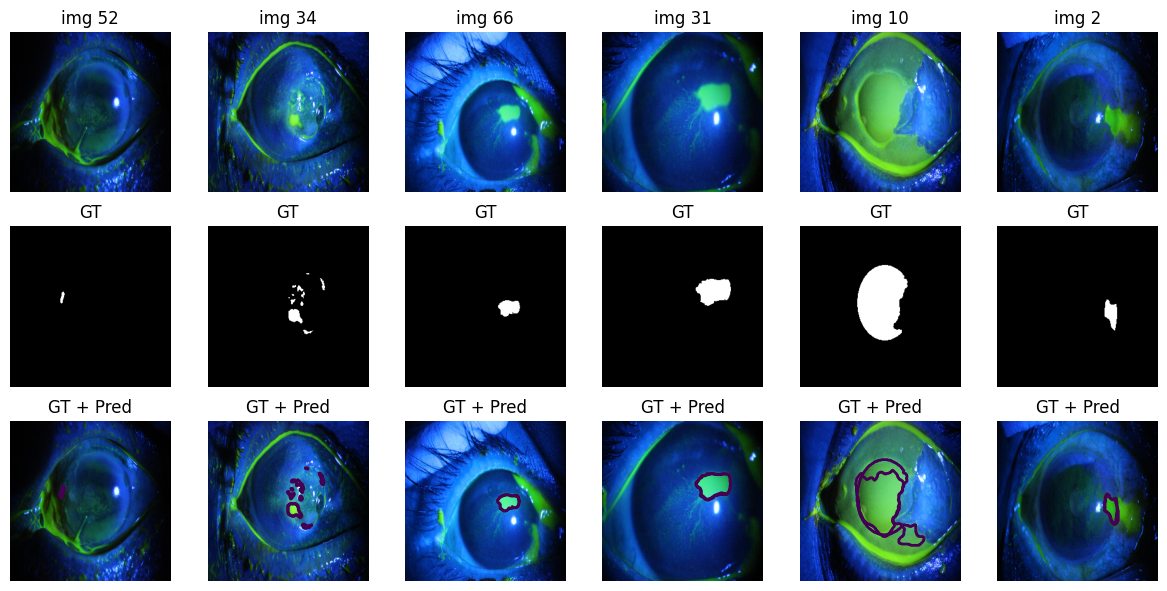

In [101]:
def show_random_overlays(model, X, Y_ulcer, n=6, threshold=0.5, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=n, replace=False)

    probs = model.predict(X[idxs], verbose=0)[...,0]
    pred  = (probs > threshold).astype(np.uint8)
    gt    = Y_ulcer[idxs,...,0].astype(np.uint8)

    plt.figure(figsize=(12, 6))
    for j,i in enumerate(idxs):
        ax = plt.subplot(3, n, j+1)
        ax.imshow(X[i]); ax.axis("off"); ax.set_title(f"img {i}")

        ax = plt.subplot(3, n, n+j+1)
        ax.imshow(gt[j], cmap="gray"); ax.axis("off"); ax.set_title("GT")

        ax = plt.subplot(3, n, 2*n+j+1)
        ax.imshow(X[i])
        ax.contour(gt[j], levels=[0.5], linewidths=2)
        ax.contour(pred[j], levels=[0.5], linewidths=2)
        ax.axis("off"); ax.set_title("GT + Pred")
    plt.tight_layout()
    plt.show()

show_random_overlays(modelReal, X_test_eval, Y_test_eval, n=6, threshold=0.5, seed=1)


# Conclusion
1.  Dice measures how well the predicted ulcer region overlaps with the ground truth annotation. A Dice score of 1 means perfect overlap and 0 means no overlap. It is particularly suitable for medical segmentation because it is sensitive to small structures such as ulcers.


2.   IoU measures the ratio between the intersection and the union of the predicted and ground truth regions. It is stricter than Dice and penalises over segmentation more strongly

3.  The mean reflects overall performance while the median reflects typical performance. The median being higher indicates that most images are segmented well with a small number of difficult cases lowering the mean

3.   When evaluated directly on slit-lamp images without any region restriction, the model achieves a mean Dice score of approximately 0.72 and a median Dice score of 0.82, with a corresponding mean IoU of about 0.62

4.   The model achieves a mean Dice score of 0.75 and a median Dice score of 0.83 when evaluated within the corneal ROI with a corresponding mean IoU of 0.66.

5.   Without ROI, the evaluation reflects overall robustness on raw slit lamp images. With ROI, evaluation focuses on the clinically relevant corneal region and reduces background dominance leading to improved Dice and IoU

In [35]:
#making sure everythign seems right
print("Dice range:", d_real.min(), d_real.max())
print("IoU range:", i_real.min(), i_real.max())
print("X_test:", X_test.shape)
print("Y_test_ulcer:", Y_test_ulcer.shape)
print("probs_real:", probs_real.shape)
print("pred_real:", pred_real.shape)
print("GT unique:", np.unique(Y_test_ulcer))
print("Pred unique:", np.unique(pred_real))

Dice range: 1.2987012818350482e-08 0.9862613981779621
IoU range: 1.2987012818350482e-08 0.9728951787064295
X_test: (72, 256, 256, 3)
Y_test_ulcer: (72, 256, 256, 1)
probs_real: (72, 256, 256)
pred_real: (72, 256, 256)
GT unique: [0 1]
Pred unique: [0 1]


In [40]:
#checking the worst case segmentation
worst= np.argmin(d_real)
print("Worst index:", worst, "Dice:", d_real[worst], "IoU:", i_real[worst])
gt_sum= Y_test_ulcer[worst,...,0].sum()
pred_sum= pred_real[worst].sum()
print("GT ulcer pixels:", gt_sum, "Pred ulcer pixels:", pred_sum)

Worst index: 52 Dice: 1.2987012818350482e-08 IoU: 1.2987012818350482e-08
GT ulcer pixels: 77 Pred ulcer pixels: 0


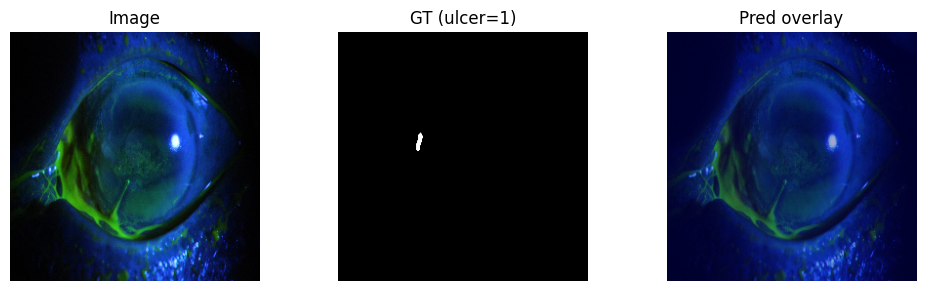

In [37]:
show_pred(worst)
# the model missed the ulcer completely in the worst case because of how small it is in the image that is why we got worst dice closer to zero

1.   Some test images contain very small or atypical ulcers. If the model misses these entirely, Dice collapses to near zero. This reflects failure cases rather than overall performance, which is why median and ROI-based metrics are also reported.



/tmp/ipython-input-3826474462.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_real, d_real_roi], labels=["No ROI", "ROI"])
/tmp/ipython-input-3826474462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([i_real, i_real_roi], labels=["No ROI", "ROI"])


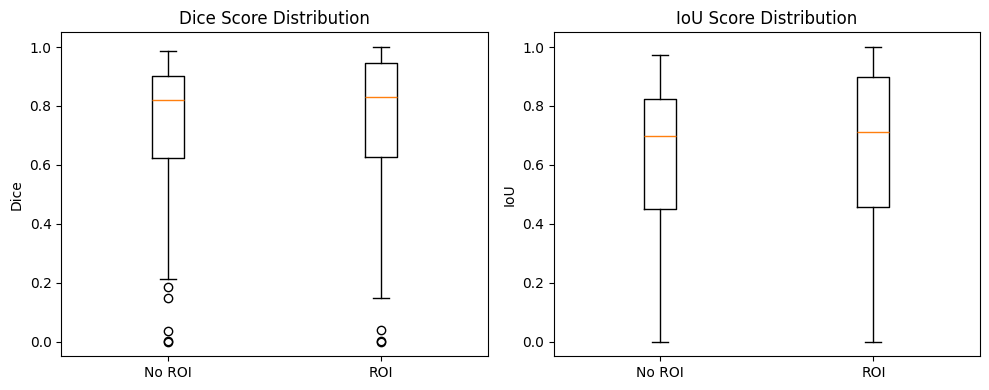

In [39]:
# box plots showing the distributions of both dice and iou scores

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.boxplot([d_real, d_real_roi], labels=["No ROI", "ROI"])
plt.title("Dice Score Distribution")
plt.ylabel("Dice")

plt.subplot(1,2,2)
plt.boxplot([i_real, i_real_roi], labels=["No ROI", "ROI"])
plt.title("IoU Score Distribution")
plt.ylabel("IoU")

plt.tight_layout()
plt.show()

# Synthetic +real data model

my approach to this was to Pretrain on synthetic then fine-tune on real only data. This usually works much better than naive mixing.
1.  Stage 1: train on synthetic only for a few epochs
2.  Stage 2: fine-tune on real only (this is what matters for performance)

In [31]:
import os, glob

AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE= (256, 256)

X_train= X_train.astype(np.float32)
Y_train_ulcer = Y_train_ulcer.astype(np.uint8)
if Y_train_ulcer.ndim == 3: Y_train_ulcer = Y_train_ulcer[..., None]

X_val = X_val.astype(np.float32)
Y_val_ulcer = Y_val_ulcer.astype(np.uint8)
if Y_val_ulcer.ndim == 3: Y_val_ulcer = Y_val_ulcer[..., None]

# using tf.data because It pipelines loading + preprocessing in parallel and reduces CPU/GPU idle time and scales better than Python loops
batch_size_real= 2
ds_real= tf.data.Dataset.from_tensor_slices((X_train, Y_train_ulcer)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .batch(batch_size_real) \
    .prefetch(AUTOTUNE)

#ensures I dont loose partial last batch
steps_real= int(np.ceil(len(X_train) / batch_size_real))

syn_img_dir= os.path.join(BASE, "synthetic_v3/images")
syn_msk_dir = os.path.join(BASE, "synthetic_v3/ulcer_masks")

syn_img_paths= sorted(glob.glob(os.path.join(syn_img_dir,"*.png")))
syn_msk_paths  =[os.path.join(syn_msk_dir, os.path.basename(p)) for p in syn_img_paths]

print("Synthetic count:",len(syn_img_paths))

#I used TensorFlow-based file loader
def loadSyn(imgPath, mskPath):
  img = tf.io.read_file(imgPath)
  img = tf.image.decode_png(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]

  msk = tf.io.read_file(mskPath)
  msk = tf.image.decode_png(msk, channels=1)
  msk = tf.cast(msk > 0, tf.uint8)  # ulcer=1
  return img, msk

batch_size_syn = 2

#standard tf.data pipeline for image datasets
ds_syn = tf.data.Dataset.from_tensor_slices((syn_img_paths, syn_msk_paths)) \
    .shuffle(512, reshuffle_each_iteration=True) \
    .map(loadSyn, num_parallel_calls=AUTOTUNE) \
    .batch(batch_size_syn) \
    .prefetch(AUTOTUNE)

steps_syn = max(1, int(np.ceil(len(syn_img_paths) / batch_size_syn)))


Synthetic count: 2964


In [32]:
tf.keras.backend.clear_session()
model = buildUnet(X_train.shape[1:])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=focal_tversky_loss)

pre_ckpt = "/content/drive/MyDrive/Corneal_ulcer_model/models/pretrain_synthetic.keras"

cb_pre = [tf.keras.callbacks.ModelCheckpoint(pre_ckpt, save_best_only=True, monitor="val_loss"),tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),]

hist_pre = model.fit(
    ds_syn,
    validation_data=(X_val, Y_val_ulcer),   # I validate on REAL so we don’t overfit synthetic
    epochs=10,                               # small number fo epochs
    steps_per_epoch=steps_syn,
    callbacks=cb_pre,
    verbose=1
)


Epoch 1/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 127s 72ms/step - loss: 0.1159 - val_loss: 0.9949
Epoch 2/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 108s 56ms/step - loss: 0.0329 - val_loss: 0.9944
Epoch 3/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - loss: 0.0158 - val_loss: 0.9912
Epoch 4/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - loss: 0.0098 - val_loss: 0.9930
Epoch 5/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - loss: 0.0075 - val_loss: 0.9923
Epoch 6/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - loss: 0.0058 - val_loss: 0.9872
Epoch 7/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - loss: 0.0059 - val_loss: 0.9892
Epoch 8/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - loss: 0.0044 - val_loss: 0.9893
Epoch 9/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 141s 55ms/step - loss: 0.0047 - val_loss: 0.9900
Epoch 10/10
1482/1482 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - loss: 0.0039 - val_loss: 0.9902


In [33]:
ft_ckpt = "/content/drive/MyDrive/Corneal_ulcer_mode/MixedDataModel.keras"
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss=focal_tversky_loss)

cb_ft = [tf.keras.callbacks.ModelCheckpoint(ft_ckpt, save_best_only=True, monitor="val_loss"),tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss"),]

hist_ft = model.fit(
    ds_real,
    validation_data=(X_val, Y_val_ulcer),
    epochs=60,
    steps_per_epoch=steps_real,
    callbacks=cb_ft,
    verbose=1
)


Epoch 1/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 40s 155ms/step - loss: 0.9819 - val_loss: 0.9594
Epoch 2/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.9737 - val_loss: 0.9594
Epoch 3/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.9690 - val_loss: 0.9594
Epoch 4/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.9661 - val_loss: 0.9593
Epoch 5/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - loss: 0.9675 - val_loss: 0.9593
Epoch 6/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.9659 - val_loss: 0.9417
Epoch 7/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.9488 - val_loss: 0.9296
Epoch 8/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 0.9311 - val_loss: 0.8968
Epoch 9/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.9043 - val_loss: 0.8854
Epoch 10/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.9065 - val_loss: 0.8747
Epoch 11/60
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.9072 - val_loss: 0.8819
Epoch 12/60
124/124 ━━━━━━━━━━━━━━━━━━

In [102]:
REALPATH = "/content/drive/MyDrive/Corneal_ulcer_model/models/RealDataModelv2.keras"
MIXEDPATH= "/content/drive/MyDrive/Corneal_ulcer_model/models/MixedDataModel.keras"

# Load models
baseline_model = tf.keras.models.load_model(
    REALPATH, custom_objects={"focal_tversky_loss": focal_tversky_loss}
)
ft_model = tf.keras.models.load_model(
    MIXEDPATH, custom_objects={"focal_tversky_loss": focal_tversky_loss}
)

X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
  Y_test_eval = Y_test_eval[..., None]

out = evalModel(baseline_model, X_test_eval, Y_test_eval, threshold=0.5, useRoi=False)
d_base, i_base = out[0], out[1]
out = evalModel(ft_model, X_test_eval, Y_test_eval, threshold=0.5, useRoi=False)
d_ft, i_ft = out[0], out[1]

print("No ROI")
print("REAL Dice mean/median:", d_base.mean(),np.median(d_base), " IoU mean/median:", i_base.mean(), np.median(i_base))
print("MIXED  Dice mean/median:", d_ft.mean(),  np.median(d_ft),  " IoU mean/median:", i_ft.mean(), np.median(i_ft))

out = evalModel(baseline_model, X_test_eval, Y_test_eval, threshold=0.5, useRoi=True)
d_base_roi, i_base_roi = out[0], out[1]
out = evalModel(ft_model, X_test_eval, Y_test_eval, threshold=0.5, useRoi=True)
d_ft_roi, i_ft_roi = out[0], out[1]

print("\n WITH ROI ")
print("BASELINE Dice mean/median:", d_base_roi.mean(), np.median(d_base_roi), " IoU mean/median:", i_base_roi.mean(), np.median(i_base_roi))
print("FT       Dice mean/median:", d_ft_roi.mean(),   np.median(d_ft_roi),  " IoU mean/median:", i_ft_roi.mean(),   np.median(i_ft_roi))

print("\nFinal Best Chosen Model")
print("No ROI:", "FT" if d_ft.mean() > d_base.mean() else "Real")
print("ROI  :", "FT" if d_ft_roi.mean() > d_base_roi.mean() else "Real")


No ROI
REAL Dice mean/median: 0.7063836758998205 0.8093786015843996  IoU mean/median: 0.6024513933771898 0.6797975798393685
MIXED  Dice mean/median: 0.6587127611905289 0.7163906465011907  IoU mean/median: 0.5302154846706831 0.5581329541539397

 WITH ROI 
BASELINE Dice mean/median: 0.7521621269097074 0.8244177440670126  IoU mean/median: 0.6637487495573282 0.7013375504115231
FT       Dice mean/median: 0.7119896234184804 0.7754624099397104  IoU mean/median: 0.6081617356299889 0.633269592320362

Final Best Chosen Model
No ROI: Real
ROI  : Real


In [103]:
import pandas as pd
def summarise_metrics(dice, iou, model_name, setting):
  return {
        "Model": model_name,
        "Setting": setting,
        "Dice mean": np.mean(dice),
        "Dice median": np.median(dice),
        "Dice std": np.std(dice),
        "IoU mean": np.mean(iou),
        "IoU median": np.median(iou),
        "N images": len(dice)
    }
rows = []

#No ROI
rows.append(summarise_metrics(d_base,i_base, "Baseline (real only v2 )", "No ROI"))
rows.append(summarise_metrics(d_ft,i_ft,"Fine-tuned (syn -> real)", "No ROI"))

#with ROI
rows.append(summarise_metrics(d_base_roi, i_base_roi, "Baseline (real only v2)", "ROI"))
rows.append(summarise_metrics(d_ft_roi,   i_ft_roi,"Fine-tuned (syn -> real)","ROI"))

df_results = pd.DataFrame(rows)
df_results = df_results.round(4)

df_results


,Model,Setting,Dice mean,Dice median,Dice std,IoU mean,IoU median,N images
0,Baseline (real only v2 ),No ROI,0.7064,0.8094,0.2664,0.6025,0.6798,72
1,Fine-tuned (syn -> real),No ROI,0.6587,0.7164,0.2273,0.5302,0.5581,72
2,Baseline (real only v2),ROI,0.7522,0.8244,0.2661,0.6637,0.7013,72
3,Fine-tuned (syn -> real),ROI,0.7120,0.7755,0.2546,0.6082,0.6333,72


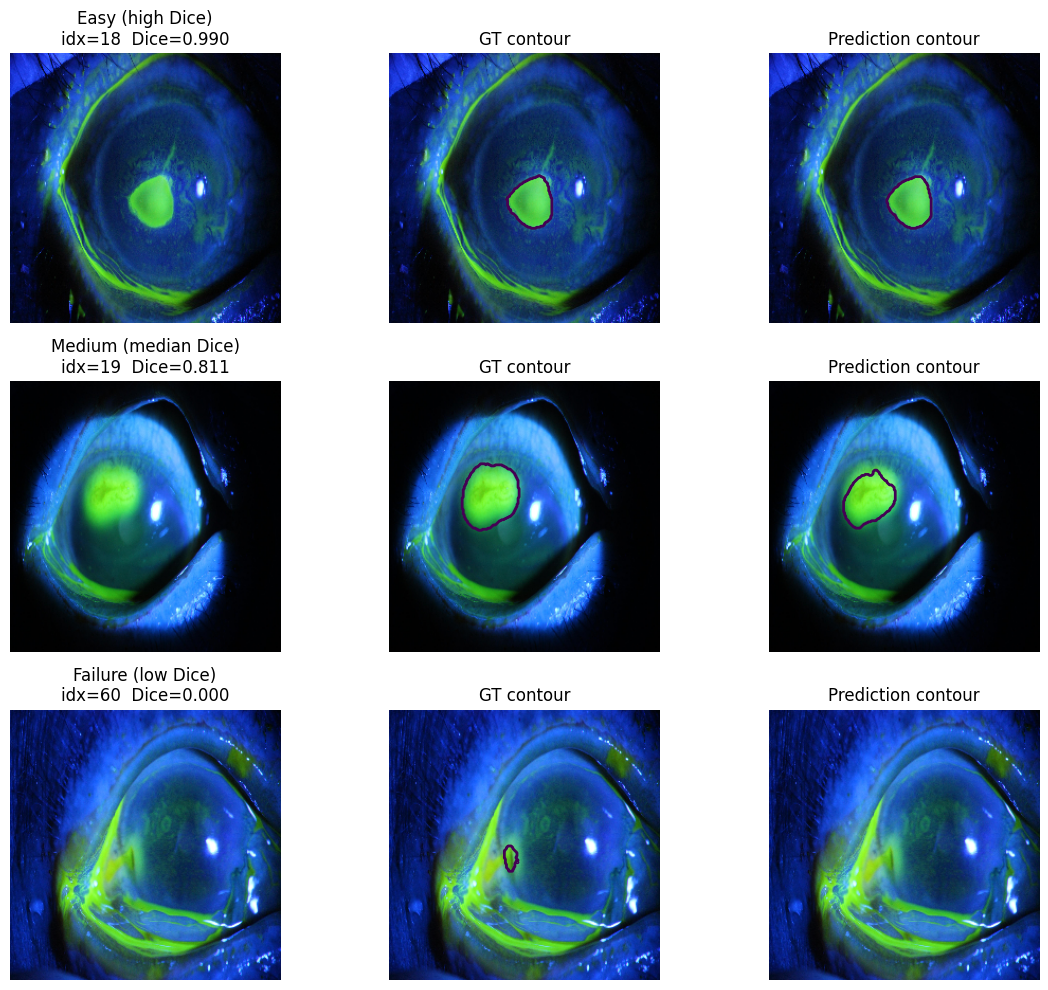

Saved: /content/drive/MyDrive/Corneal_ulcer_model/qualitative_examples_contours_real_only.png
Picked indices (best, median, worst): [18, 19, 60]
Dice at picked indices: [0.9897723523623317, 0.8108229989152597, 4.694835658709691e-09]


In [97]:
def dice_np(a, b, eps=1e-6):
  a = a.reshape(-1); b = b.reshape(-1)
  return (2*(a*b).sum() + eps) / (a.sum() + b.sum() + eps)

def predictPick(model, X, Y, threshold=0.5):
    probs= model.predict(X, verbose=0)[..., 0]
    pred= (probs > threshold).astype(np.uint8)
    gt =  Y[..., 0].astype(np.uint8)
    dices= np.array([dice_np(gt[i], pred[i]) for i in range(len(gt))])
    order =  np.argsort(dices)
    worst= int(order[0])
    best= int(order[-1])
    median = int(order[len(order)//2])
    return dices, probs, pred, [best, median, worst]

def saveContourGrid(X, Y, pred_bin, dices, indices, out_path):
    titles = ["Easy (high Dice)", "Medium (median Dice)", "Failure (low Dice)"]
    plt.figure(figsize=(12, 10))

    for r, idx in enumerate(indices):
        img = X[idx]
        gt  = Y[idx, :, :, 0].astype(np.uint8)
        pr  = pred_bin[idx].astype(np.uint8)

        ax = plt.subplot(len(indices), 3, r*3 + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{titles[r]}\nidx={idx}  Dice={dices[idx]:.3f}")

        ax = plt.subplot(len(indices), 3, r*3 + 2)
        ax.imshow(img)
        ax.contour(gt, levels=[0.5], linewidths=2)
        ax.axis("off")
        ax.set_title("GT contour")

        ax = plt.subplot(len(indices), 3, r*3 + 3)
        ax.imshow(img)
        ax.contour(pr, levels=[0.5], linewidths=2)
        ax.axis("off")
        ax.set_title("Prediction contour")

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
    Y_test_eval = Y_test_eval[..., None]

dices, probs, pred_bin, picks = predictPick(modelReal, X_test_eval, Y_test_eval, threshold=0.5)

out_fig = "/content/drive/MyDrive/Corneal_ulcer_model/qualitative_examples_contours_real_only.png"
saveContourGrid(X_test_eval, Y_test_eval, pred_bin, dices, picks, out_fig)

print("Picked indices (best, median, worst):", picks)
print("Dice at picked indices:", [float(dices[i]) for i in picks])


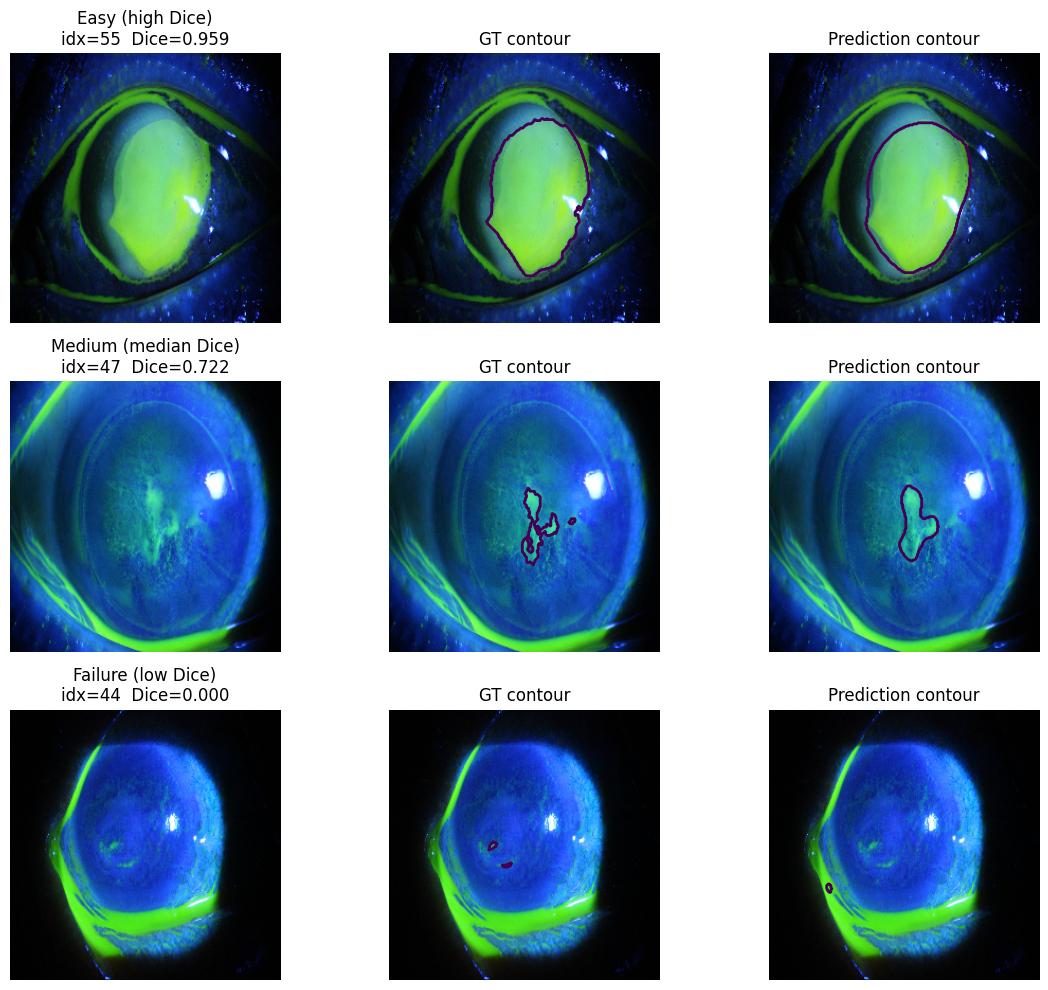

Saved: /content/drive/MyDrive/Corneal_ulcer_model/qualitative_examples_contours_mixed_only.png
Picked indices (best, median, worst): [55, 47, 44]
Dice at picked indices: [0.959481517044672, 0.7216856893232285, 1.2987012818350482e-08]


In [96]:
def dice_np(a, b, eps=1e-6):
  a = a.reshape(-1); b = b.reshape(-1)
  return (2*(a*b).sum() + eps) / (a.sum() + b.sum() + eps)

def predictPick(model, X, Y, threshold=0.5):
    probs= model.predict(X, verbose=0)[..., 0]
    pred= (probs > threshold).astype(np.uint8)
    gt =  Y[..., 0].astype(np.uint8)
    dices= np.array([dice_np(gt[i], pred[i]) for i in range(len(gt))])
    order =  np.argsort(dices)
    worst= int(order[0])
    best= int(order[-1])
    median = int(order[len(order)//2])
    return dices, probs, pred, [best, median, worst]

def saveContourGrid(X, Y, pred_bin, dices, indices, out_path):
    titles = ["Easy (high Dice)", "Medium (median Dice)", "Failure (low Dice)"]
    plt.figure(figsize=(12, 10))

    for r, idx in enumerate(indices):
        img = X[idx]
        gt  = Y[idx, :, :, 0].astype(np.uint8)
        pr  = pred_bin[idx].astype(np.uint8)

        ax = plt.subplot(len(indices), 3, r*3 + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{titles[r]}\nidx={idx}  Dice={dices[idx]:.3f}")

        ax = plt.subplot(len(indices), 3, r*3 + 2)
        ax.imshow(img)
        ax.contour(gt, levels=[0.5], linewidths=2)
        ax.axis("off")
        ax.set_title("GT contour")

        ax = plt.subplot(len(indices), 3, r*3 + 3)
        ax.imshow(img)
        ax.contour(pr, levels=[0.5], linewidths=2)
        ax.axis("off")
        ax.set_title("Prediction contour")

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


X_test_eval = X_test.astype(np.float32)
Y_test_eval = Y_test_ulcer.astype(np.uint8)
if Y_test_eval.ndim == 3:
    Y_test_eval = Y_test_eval[..., None]

dices, probs, pred_bin, picks = predictPick(ft_model, X_test_eval, Y_test_eval, threshold=0.5)

out_fig = "/content/drive/MyDrive/Corneal_ulcer_model/qualitative_examples_contours_mixed_only.png"
saveContourGrid(X_test_eval, Y_test_eval, pred_bin, dices, picks, out_fig)

print("Picked indices (best, median, worst):", picks)
print("Dice at picked indices:", [float(dices[i]) for i in picks])


In [42]:
# current prediction
probs = modelReal.predict(X_test_eval, verbose=0)
if probs.shape[-1] == 2:
    pred = (np.argmax(probs, axis=-1)).astype(np.uint8)
else:
    pred = (probs[...,0] > 0.5).astype(np.uint8)

gt = Y_test_eval[...,0].astype(np.uint8)

def dice_np(a,b,eps=1e-6):
    a=a.reshape(-1); b=b.reshape(-1)
    return (2*(a*b).sum()+eps)/(a.sum()+b.sum()+eps)

dice_normal = np.mean([dice_np(gt[i], pred[i]) for i in range(len(gt))])
dice_invertGT = np.mean([dice_np(1-gt[i], pred[i]) for i in range(len(gt))])

print("Mean Dice vs GT:", dice_normal)
print("Mean Dice vs (1-GT):", dice_invertGT)


Mean Dice vs GT: 0.0473483978889107
Mean Dice vs (1-GT): 0.14868192322073615


In [43]:
gt = Y_test_eval[...,0].astype(np.uint8)
print("GT min/max:", gt.min(), gt.max())
print("GT foreground fraction (mean):", gt.mean())


GT min/max: 0 1
GT foreground fraction (mean): 0.0418641832139757
